# 📧 Email Spam Detection
**Intelligent Programming Project**

Classify emails as **Spam** or **Ham (Not Spam)** using Machine Learning.

---

## 1️⃣ Import Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    classification_report, confusion_matrix
)

print(' Libraries imported successfully!')

 Libraries imported successfully!


## 2️⃣ Load Dataset

> Using the **SMS Spam Collection Dataset**.
> You can download it from: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
>
> Place `spam.csv` in the same folder as this notebook.

In [2]:
# Load dataset
df = pd.read_csv('spam.csv', encoding='latin-1')

# Keep only relevant columns
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

print(f'Dataset Shape: {df.shape}')
print(f'\nLabel Distribution:')
print(df['label'].value_counts())
df.head(10)

Dataset Shape: (5572, 2)

Label Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


## 3️⃣ Exploratory Data Analysis (EDA)

In [3]:
# Check for missing values
print('Missing Values:')
print(df.isnull().sum())

# Message length analysis
df['msg_length'] = df['message'].apply(len)

print(f'\nAverage message length (Ham):  {df[df["label"]=="ham"]["msg_length"].mean():.1f} chars')
print(f'Average message length (Spam): {df[df["label"]=="spam"]["msg_length"].mean():.1f} chars')

Missing Values:
label      0
message    0
dtype: int64

Average message length (Ham):  71.0 chars
Average message length (Spam): 138.9 chars


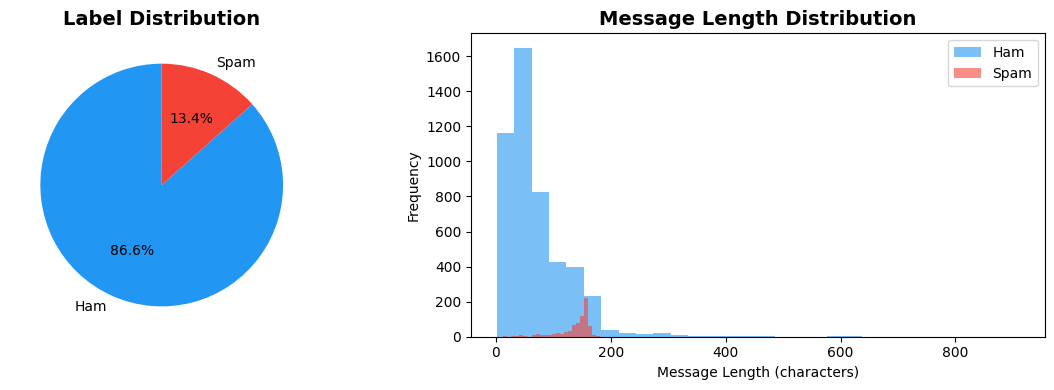

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Label distribution pie chart
label_counts = df['label'].value_counts()
axes[0].pie(label_counts, labels=['Ham', 'Spam'], autopct='%1.1f%%',
            colors=['#2196F3', '#F44336'], startangle=90)
axes[0].set_title('Label Distribution', fontsize=14, fontweight='bold')

# Message length distribution
df[df['label']=='ham']['msg_length'].plot(kind='hist', ax=axes[1],
    alpha=0.6, color='#2196F3', label='Ham', bins=30)
df[df['label']=='spam']['msg_length'].plot(kind='hist', ax=axes[1],
    alpha=0.6, color='#F44336', label='Spam', bins=30)
axes[1].set_title('Message Length Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Message Length (characters)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4️⃣ Text Preprocessing

In [5]:
# English stopwords (no external library needed)
STOPWORDS = set([
    'i','me','my','myself','we','our','ours','ourselves','you','your','yours',
    'yourself','he','him','his','himself','she','her','hers','herself','it','its',
    'itself','they','them','their','theirs','themselves','what','which','who','whom',
    'this','that','these','those','am','is','are','was','were','be','been','being',
    'have','has','had','having','do','does','did','doing','a','an','the','and','but',
    'if','or','because','as','until','while','of','at','by','for','with','about',
    'against','between','into','through','during','before','after','above','below',
    'to','from','up','down','in','out','on','off','over','under','again','further',
    'then','once','here','there','when','where','why','how','all','both','each',
    'few','more','most','other','some','such','no','nor','not','only','own','same',
    'so','than','too','very','s','t','can','will','just','don','should','now'
])

def preprocess_text(text):
    """Clean and preprocess text for classification."""
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove special characters and punctuation
    text = re.sub(r'[^a-z\s]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # Remove stopwords and short words
    tokens = text.split()
    tokens = [w for w in tokens if w not in STOPWORDS and len(w) > 2]
    return ' '.join(tokens)

# Apply preprocessing
df['clean_text'] = df['message'].apply(preprocess_text)

print('✅ Text preprocessing done!')
print('\nExample:')
print(f'Original : {df["message"].iloc[0]}')
print(f'Cleaned  : {df["clean_text"].iloc[0]}')

✅ Text preprocessing done!

Example:
Original : Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Cleaned  : jurong point crazy available bugis great world buffet cine got amore wat


## 5️⃣ Convert Text to Numbers (TF-IDF)

In [6]:
# Encode labels
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'],
    df['label_num'],
    test_size=0.2,
    random_state=42,
    stratify=df['label_num']
)

print(f'Training samples : {len(X_train)}')
print(f'Testing samples  : {len(X_test)}')

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'\nTF-IDF Matrix shape (train): {X_train_tfidf.shape}')
print('✅ Text converted to numerical features!')

Training samples : 4457
Testing samples  : 1115

TF-IDF Matrix shape (train): (4457, 5000)
✅ Text converted to numerical features!


## 6️⃣ Train Classifier (Naive Bayes)

In [7]:
# Train Multinomial Naive Bayes
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

print('✅ Model trained successfully!')

✅ Model trained successfully!


## 7️⃣ Evaluate Model

In [8]:
# Predictions
y_pred = model.predict(X_test_tfidf)

# Metrics
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print('=' * 40)
print('        MODEL EVALUATION RESULTS')
print('=' * 40)
print(f'  Accuracy  : {accuracy*100:.2f}%')
print(f'  Precision : {precision*100:.2f}%')
print(f'  Recall    : {recall*100:.2f}%')
print(f'  F1-Score  : {f1*100:.2f}%')
print('=' * 40)
print()
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

        MODEL EVALUATION RESULTS
  Accuracy  : 96.68%
  Precision : 99.12%
  Recall    : 75.84%
  F1-Score  : 85.93%

              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       0.99      0.76      0.86       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



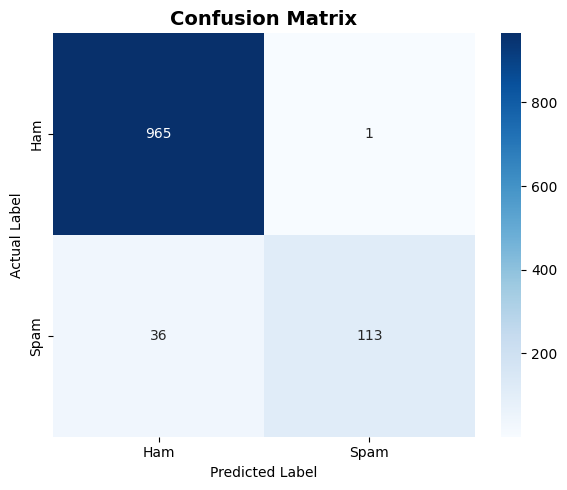

In [9]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

## 8️⃣ Predict New Email

In [10]:
def predict_email(text):
    """Predict if an email is spam or ham."""
    cleaned = preprocess_text(text)
    vectorized = tfidf.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    probability = model.predict_proba(vectorized)[0]
    
    label = 'SPAM 🚨' if prediction == 1 else 'HAM ✅'
    confidence = probability[prediction] * 100
    
    print(f'Email   : {text[:80]}...' if len(text) > 80 else f'Email   : {text}')
    print(f'Result  : {label}')
    print(f'Confidence: {confidence:.2f}%')
    
    if prediction == 1:
        print('⚠️  WARNING: This email looks suspicious! Do NOT click any links or share personal information.')
    
    print('-' * 60)

# Test examples
test_emails = [
    "WINNER!! You have been selected to receive a $1000 prize. Call now to claim!",
    "Hey, are you coming to the team meeting at 3pm today?",
    "Congratulations! You won a free iPhone. Click here to claim your prize now!",
    "Can you please send me the project report by tomorrow morning?"
]

print('=' * 60)
print('           EMAIL SPAM DETECTOR')
print('=' * 60)
for email in test_emails:
    predict_email(email)

           EMAIL SPAM DETECTOR
Email   : WINNER!! You have been selected to receive a $1000 prize. Call now to claim!
Result  : SPAM 🚨
Confidence: 98.55%
⚠️  WARNING: This email looks suspicious! Do NOT click any links or share personal information.
------------------------------------------------------------
Email   : Hey, are you coming to the team meeting at 3pm today?
Result  : HAM ✅
Confidence: 99.09%
------------------------------------------------------------
Email   : Congratulations! You won a free iPhone. Click here to claim your prize now!
Result  : SPAM 🚨
Confidence: 97.18%
⚠️  WARNING: This email looks suspicious! Do NOT click any links or share personal information.
------------------------------------------------------------
Email   : Can you please send me the project report by tomorrow morning?
Result  : HAM ✅
Confidence: 98.11%
------------------------------------------------------------


## 9️⃣ Try Your Own Email

In [11]:
# ✏️ Type your own email here
my_email = "Type your email message here to test"

predict_email(my_email)

Email   : Type your email message here to test
Result  : HAM ✅
Confidence: 97.53%
------------------------------------------------------------


---
## ✅ Summary

| Step | Description |
|------|-------------|
| Dataset | SMS Spam Collection (5,574 messages) |
| Preprocessing | Lowercase, remove URLs/numbers/punctuation, stopwords removal |
| Vectorization | TF-IDF (5000 features, unigrams + bigrams) |
| Classifier | Multinomial Naive Bayes |
| Train/Test Split | 80% / 20% |
| Evaluation | Accuracy, Precision, Recall, F1-Score |
| Bonus | Warning messages + Streamlit UI |